# Results exploration

This notebook explores some results (distances, correlations, climate analogs).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Distance distribution

In [3]:
# Load distance matrices

periods = ['1940-1970', '2021-2050']
scenarios = ['ssp126', 'ssp370', 'ssp585']
distances = ['euclidean', 'mahalanobis']
types = ['all', 'embedding', 'pca']

distance_matrices = {}

for type in types:
    for period in periods:
        for distance in distances:
            if period in ['1940-1970', '1994-2024']:
                filename = f'distance_matrices/{type}_{distance}_{period}.csv'
            else:
                for scenario in scenarios:
                    filename = f'distance_matrices/{type}_{distance}_{period}_{scenario}.csv'
            
            key = f'{type}_{period}_{distance}' if period == '1940-1970' else f'{type}_{scenario}_{period}_{distance}'
            distance_matrices[key] = pd.read_csv(filename, index_col=0)


In [4]:
def plot_distance_distribution(distances, title_prefix="", figsize=(12, 5)):
    """
    Affiche la distribution des distances avec histogramme et boxplot.
    
    Parameters:
    -----------
    distances : array-like
        Tableau de distances à visualiser
    title_prefix : str, optional
        Préfixe à ajouter aux titres des graphiques
    figsize : tuple, optional
        Taille de la figure (largeur, hauteur)
    
    Returns:
    --------
    dict : Statistiques descriptives des distances
    """
    plt.figure(figsize=figsize)
    
    # Histogramme
    plt.subplot(1, 2, 1)
    plt.hist(distances, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel('Distance', fontsize=11)
    plt.ylabel('Fréquence', fontsize=11)
    plt.title(f'{title_prefix}Distribution des distances', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(distances, vert=True)
    plt.ylabel('Distance', fontsize=11)
    plt.title(f'{title_prefix}Boxplot des distances', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculer et afficher les statistiques
    stats = {
        'count': len(distances),
        'mean': np.mean(distances),
        'median': np.median(distances),
        'std': np.std(distances),
        'min': np.min(distances),
        'max': np.max(distances),
        'q25': np.percentile(distances, 25),
        'q75': np.percentile(distances, 75)
    }
    
    print(f"{title_prefix}Statistiques des distances:")
    print(f"  Nombre de distances: {stats['count']}")
    print(f"  Moyenne: {stats['mean']:.4f}")
    print(f"  Médiane: {stats['median']:.4f}")
    print(f"  Écart-type: {stats['std']:.4f}")
    print(f"  Min: {stats['min']:.4f}")
    print(f"  Max: {stats['max']:.4f}")
    print(f"  Q1 (25%): {stats['q25']:.4f}")
    print(f"  Q3 (75%): {stats['q75']:.4f}")
    
    return stats

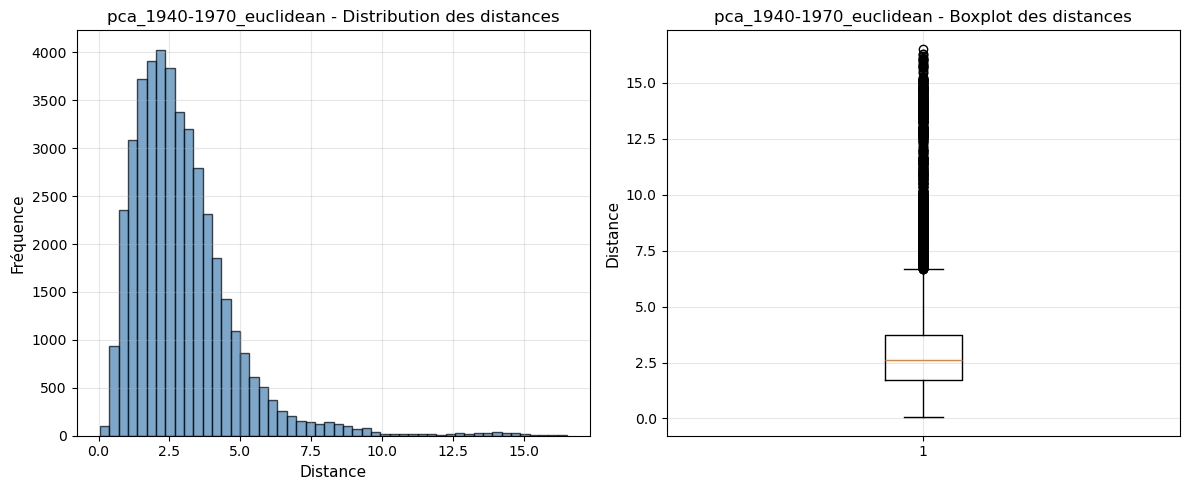

pca_1940-1970_euclidean - Statistiques des distances:
  Nombre de distances: 42195
  Moyenne: 2.9579
  Médiane: 2.6062
  Écart-type: 1.8382
  Min: 0.0530
  Max: 16.5299
  Q1 (25%): 1.7309
  Q3 (75%): 3.7175


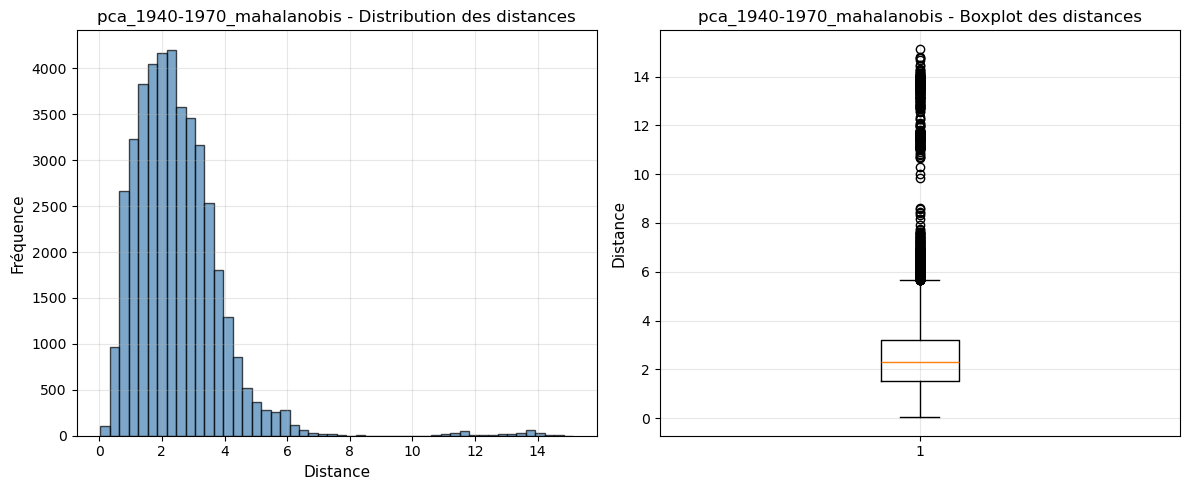

pca_1940-1970_mahalanobis - Statistiques des distances:
  Nombre de distances: 42195
  Moyenne: 2.4923
  Médiane: 2.2952
  Écart-type: 1.4533
  Min: 0.0365
  Max: 15.1388
  Q1 (25%): 1.5255
  Q3 (75%): 3.1843


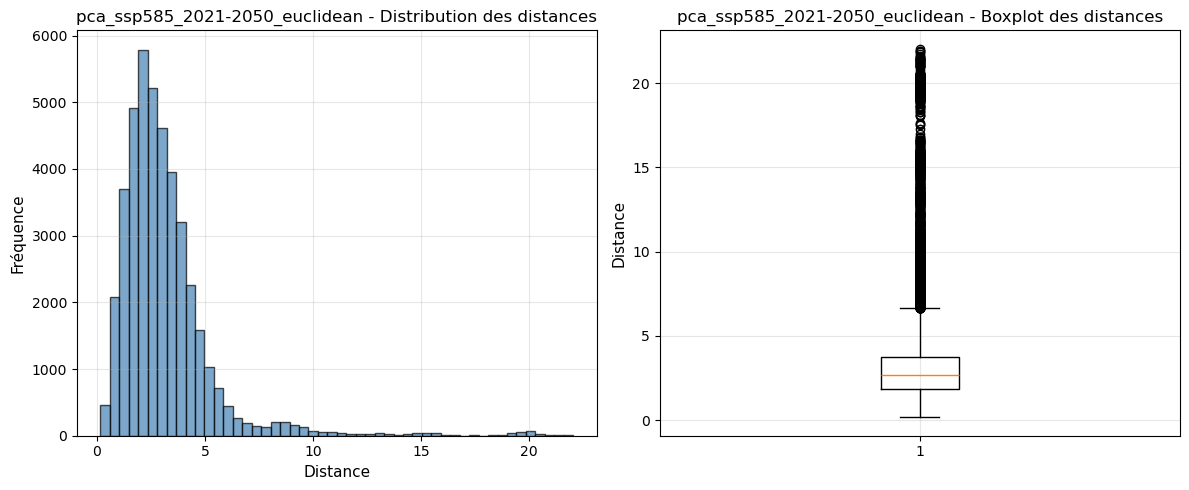

pca_ssp585_2021-2050_euclidean - Statistiques des distances:
  Nombre de distances: 42195
  Moyenne: 3.1593
  Médiane: 2.6942
  Écart-type: 2.3122
  Min: 0.1659
  Max: 22.0414
  Q1 (25%): 1.8653
  Q3 (75%): 3.7719


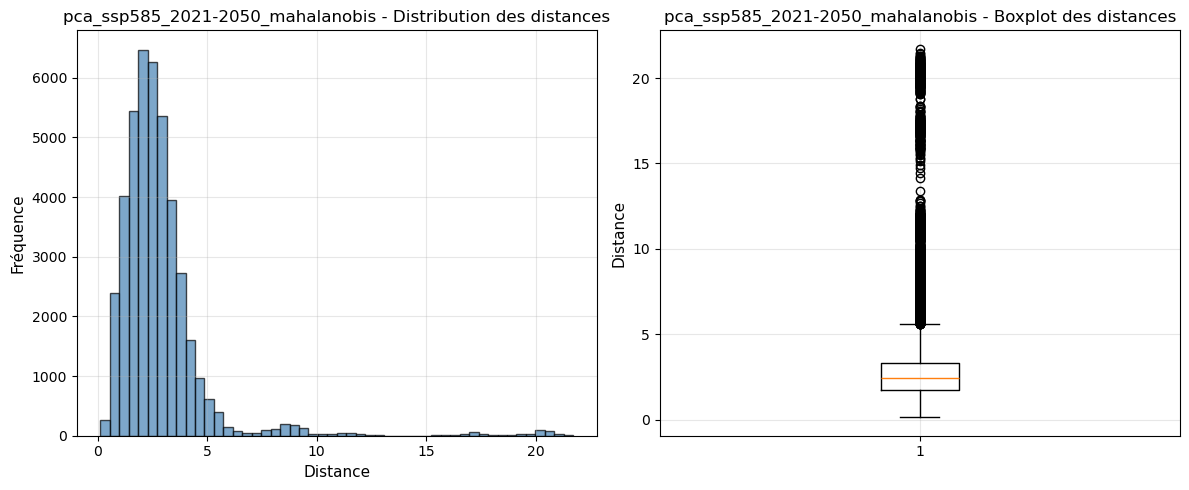

pca_ssp585_2021-2050_mahalanobis - Statistiques des distances:
  Nombre de distances: 42195
  Moyenne: 2.8481
  Médiane: 2.4574
  Écart-type: 2.2307
  Min: 0.1315
  Max: 21.7207
  Q1 (25%): 1.7458
  Q3 (75%): 3.2958


In [15]:
# display distance distribution 

for key, matrix in distance_matrices.items():
    distances_array = np.array(matrix)
    distances = distances_array[np.triu_indices_from(distances_array, k=1)]
    plot_distance_distribution(distances, title_prefix=f"{key} - ")